In [19]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [20]:
prediction_list = []

for i in range(1, 100, 4):
    predict_dataframe = pd.read_csv(f'notebook/ours_eth/predict_dict_{i}.csv')
    predict_dict = predict_dataframe.set_index('first')['second'].to_dict()
    for key in predict_dict.keys():
        data_str = predict_dict[key].strip("[]")
        matrix_1_str, matrix_2_str = data_str.split(";;;")

        # Process each part to create a (30, 10) 2D array
        def process_matrix(matrix_str):
            rows = matrix_str.strip().split(";")
            matrix = [list(map(float, row.split())) for row in rows]
            return np.array(matrix)
        
        # Convert each string part into a NumPy array of shape (30, 10)
        matrix_1 = process_matrix(matrix_1_str)
        matrix_2 = process_matrix(matrix_2_str)
        # Stack along the last axis to create a (30, 10, 2) array
        array_3d = np.stack((matrix_1, matrix_2), axis=-1)
        # Prediction horizon 10, sample number 30, dimension 2
        # 30*10*2 array
        predict_dict[key] = array_3d

    prediction_list.append(predict_dict)

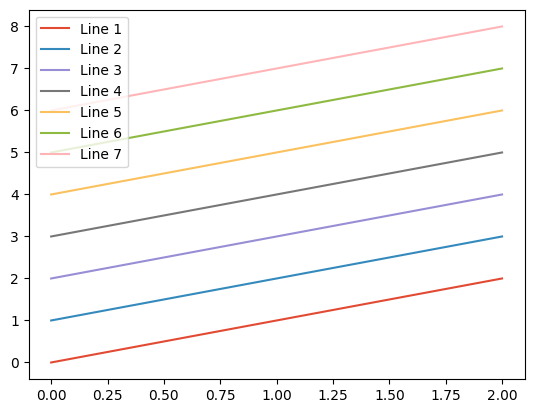

In [21]:
from matplotlib import style

style.use('ggplot')

# Retrieve the color cycle from the ggplot style
ggplot_colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

style.use('default')
# Example usage of the ggplot color palette
for i, color in enumerate(ggplot_colors):
    plt.plot([0, 1, 2], [i, i + 1, i + 2], color=color, label=f"Line {i + 1}")

plt.legend()
plt.show()

In [22]:
class StringToColorMapper:
    def __init__(self):
        self.color_map = {}  # Dictionary to store string-color mappings
        # Get a color cycle from matplotlib's 'tab10' palette
        self.colors = ggplot_colors # This provides 10 distinct colors
        self.color_index = 0  # Track the next color to use

    def _get_next_color(self):
        # Get the next color from the palette and cycle through if we run out
        color = self.colors[self.color_index]
        self.color_index = (self.color_index + 1) % len(self.colors)
        return color

    def get_color(self, string):
        # Check if the string already has a color assigned
        if string not in self.color_map:
            # Assign the next color if it's a new string
            self.color_map[string] = self._get_next_color()
        # Return the corresponding color
        return self.color_map[string]

color_mapper = StringToColorMapper()

In [23]:
def plot_predict(ax: plt.Axes, predict_dict, key):
    color = color_mapper.get_color(key)  # Get the color for the key

    for i in range(30):  # Loop through each sample (30 samples)
        x_points = predict_dict[key][i, :, 0]  # All x-coordinates for the i-th sample
        y_points = predict_dict[key][i, :, 1]  # All y-coordinates for the i-th sample
        
        # Plot the trajectory by connecting each point with a line
        ax.plot(x_points, y_points, color=color, linestyle='-', linewidth=0.5, alpha=0.5)
        ax.scatter(x_points[0], y_points[0], color=color, marker='o', s=0.5)  # Mark the start

In [24]:
def plot_trajectory(ax: plt.Axes, position_history, velocity_history, idx):
    # Plot the trajectory up to the current index
    trajectory_x = [pos[0] for pos in position_history[:idx + 1]]
    trajectory_y = [pos[1] for pos in position_history[:idx + 1]]
    ax.plot(trajectory_x, trajectory_y, 'royalblue', '-', linewidth=1)

    # Ego initial state for the hotel scenario
    # ego_pos_init_vec = [-1.5-1.393743, -8.5+2.978962]   # initial ego position [x, y] [m]
    # ego_pos_goal_vec = [3.5-1.393743, 2.978962]  # goal ego position [x, y] [m]

    # Ego initial state for eth dataset
    ego_pos_init_vec = [5.-5.263534, 0.5-5.314636]
    ego_pos_goal_vec = [5.-5.263534, 8.9-5.314636]

    # Plot an arrow for the current velocity
    current_position = position_history[idx]
    current_velocity = velocity_history[idx]
    ax.arrow(current_position[0], current_position[1], current_velocity[0], current_velocity[1],
             head_width=0.1, head_length=0.2, fc='royalblue', ec='royalblue')

    # Mark the start position
    start_position = ego_pos_init_vec
    ax.scatter(start_position[0], start_position[1], c='g', marker='o', label="Start Position", s=16)

    # Mark the current position
    ax.scatter(current_position[0], current_position[1], c='royalblue', marker='o', s=4)

    # Mark the goal position
    goal_position = ego_pos_goal_vec
    ax.scatter(goal_position[0], goal_position[1], c='royalblue', marker='*', label="Goal Position", s=16)

    ax.set_xlabel('X [m]')
    ax.set_ylabel('Y [m]')
    ax.legend(frameon=False, loc='upper left', fontsize=14)
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)

In [25]:
def plot_two_trajectory(ax: plt.Axes, position_history_1, velocity_history_1, position_history_2, velocity_history_2, idx):
    # Ego initial state for hotel dataset
    # ego_pos_init_vec = [-1.5-1.393743, -8.5+2.978962]   # initial ego position [x, y] [m]
    # ego_pos_goal_vec = [3.5-1.393743, 2.978962]  # goal ego position [x, y] [m]

    # Ego initial state for eth dataset
    ego_pos_init_vec = [5.-5.263534, 0.5-5.314636]
    ego_pos_goal_vec = [5.-5.263534, 8.9-5.314636]

    # Plot an arrow for the current velocity
    current_position_1 = position_history_1[idx]
    current_velocity_1 = velocity_history_1[idx]
    ax.arrow(current_position_1[0], current_position_1[1], current_velocity_1[0], current_velocity_1[1],
             head_width=0.1, head_length=0.2, fc='royalblue', ec='royalblue')
    
    current_position_2 = position_history_2[idx]
    current_velocity_2 = velocity_history_2[idx]
    ax.arrow(current_position_2[0], current_position_2[1], current_velocity_2[0], current_velocity_2[1],
             head_width=0.1, head_length=0.2, fc='orange', ec='orange')

    # Mark the start position
    start_position = ego_pos_init_vec
    start_marker = ax.scatter(start_position[0], start_position[1], c='royalblue', marker='o', label="Start Position", s=30)

    # Mark the current position
    ax.scatter(current_position_1[0], current_position_1[1], c='royalblue', marker='o', s=4)
    ax.scatter(current_position_2[0], current_position_2[1], c='orange', marker='o', s=4)

    # Mark the goal position
    goal_position = ego_pos_goal_vec
    goal_marker = ax.scatter(goal_position[0], goal_position[1], c='g', marker='*', label="Goal Position", s=40)

    # Plot the trajectory up to the current index
    trajectory_x_1 = [pos[0] for pos in position_history_1[:idx + 1]]
    trajectory_y_1 = [pos[1] for pos in position_history_1[:idx + 1]]
    ax.plot(trajectory_x_1, trajectory_y_1, 'royalblue', '-', linewidth=1)

    trajectory_x_2 = [pos[0] for pos in position_history_2[:idx + 1]]
    trajectory_y_2 = [pos[1] for pos in position_history_2[:idx + 1]]
    ax.plot(trajectory_x_2, trajectory_y_2, 'orange', '-', linewidth=1)

    ax.set_xlabel('X [m]')
    ax.set_ylabel('Y [m]')
    import matplotlib.lines as mlines

    # Create a custom legend
    custom_lines = [mlines.Line2D([0], [0], color='royalblue', lw=2),
                    mlines.Line2D([0], [0], color='orange', lw=2)]
    ax.legend(custom_lines + [start_marker, goal_marker], [r'$\alpha = 0.05$', r'$\alpha = 0.15$', 'Start Position', 'Goal Position'], frameon=False, loc='upper left', fontsize=14)
    # ax.legend(frameon=False, loc='upper left', fontsize=14)
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)

In [26]:
position_history_1 = np.loadtxt('notebook/ours_eth/position_history.csv', delimiter=',')
velocity_history_1 = np.loadtxt('notebook/ours_eth/velocity_history.csv', delimiter=',')

# position_history_2 = np.loadtxt('notebook/hotel_015/position_history.csv', delimiter=',')
# velocity_history_2 = np.loadtxt('notebook/hotel_015/velocity_history.csv', delimiter=',')

In [ ]:
import os
import imageio

frames = []

plt.rc('font', family='serif')
plt.rc('font', serif='Palatino')

for idx, time in enumerate(np.arange(0, 10, 0.1)):
    fig, ax = plt.subplots(figsize=(10, 6))  # Create fig and ax once per loop iteration
    ax.set_xlim(-7, 7)
    ax.set_ylim(-6, 6)
    
    # update prediction_dict every 0.4 seconds
    if idx % 4 == 0:
        predict_dict = prediction_list[idx // 4]
    

    for key in predict_dict.keys():
        plot_predict(ax, predict_dict, key)

    # plot_trajectory(ax, position_history, velocity_history, idx)
    # plot_two_trajectory(ax, position_history_1, velocity_history_1, position_history_2, velocity_history_2, idx)
    plot_trajectory(ax, position_history_1, velocity_history_1, idx)
    ax.set_title(f'Time: {time.round(1)}s')
    # plt.show()

    # Draw the figure on the canvas to make it ready for conversion
    fig.canvas.draw()

    # Convert the figure to an RGBA array
    width, height = fig.canvas.get_width_height()
    rgba = np.frombuffer(fig.canvas.tostring_argb(), dtype=np.uint8).reshape(height, width, 4)

    # Reorder from ARGB to RGBA
    rgba = rgba[:, :, [1, 2, 3, 0]]  # Rearrange the channels to RGBA

    # Append the image to the frames list
    frames.append(rgba)

    plt.close(fig)

imageio.mimsave('figures/eth.gif', frames, fps=7)